### Example code

Here we generate the connection matrix $c_{ij}$ to be diagonally dominant and include nearest neighbors.

$\beta$ and $\mu$ represent infection/contact rate per day per person. So they range from 0 to $\infty$.

A reasonable choice for $\beta$ is around 0.1, this means there is on average 1 infection per 10 days per contact.

We can also calculate the basic reproduction number to be $R_0 = \beta / \mu$ in this case.

In [1]:
import numpy as np
from core import Simulation
import matplotlib.pyplot as plt

n = 12

# Random populations
populations = np.random.uniform(1e2, 1e6, size = n)

# Seed 0.01% infection in node 0; rest fully susceptible
S0 = np.concat(([1 - 1e-4], [1,]*(n-1))) * populations
I0 = np.concat(([1e-4], [0,]*(n-1))) * populations
R0 = np.zeros(n)
init_state = np.concatenate([S0, I0, R0])

# Connection matrix (diagonally dominant)
C = np.zeros((n, n))
for i in range(n):
    nbrs = [j for j in (i-1, i+1) if 0 <= j < n]
    C[i, i] = 0.99
    for j in nbrs:
        C[i, j] = 0.01 / len(nbrs)

beta = 0.08
mu = 0.03

sim = Simulation(
    populations=populations,
    init_state=init_state,
    connection_matrix=C,
    infection_rate=beta,       
    recovery_rate=mu
)
sim.solve_system(t_end=365*3) 
t, S, I, R = sim.get_results()

In [2]:
C

array([[0.99 , 0.01 , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.005, 0.99 , 0.005, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.   , 0.005, 0.99 , 0.005, 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.005, 0.99 , 0.005, 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.005, 0.99 , 0.005, 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.005, 0.99 , 0.005, 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.005, 0.99 , 0.005, 0.   ,
        0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.005, 0.99 , 0.005,
        0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.005, 0.99 ,
        0.005, 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.005,
        0.99 , 0.005

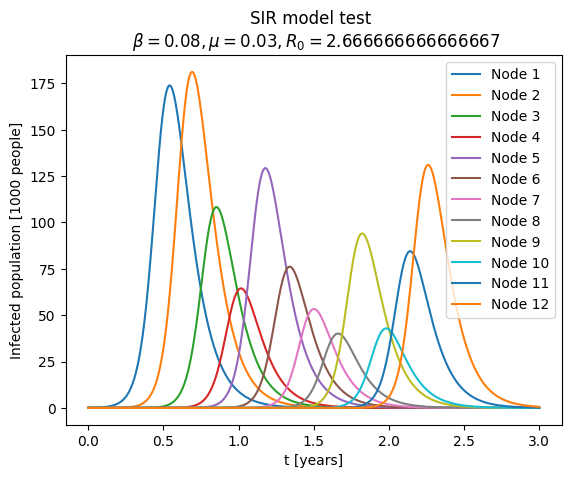

In [3]:
for i in range(n):
    plt.plot(t / 365, I[i] / 1000, label = f'Node {i+1}')
    
plt.title(f'SIR model test \n $\\beta = {beta}, \\mu = {mu}, R_0 = {beta/mu}$')
plt.xlabel('t [years]')
plt.ylabel('Infected population [1000 people]')
plt.legend()